# Projekt 3: Warum hat mein Modell das vorhergesagt?
## KI-gestützte Produktivitätssteigerung - Fokus: Vertrauen & Transparenz

Dieses Projekt analysiert klinische Merkmale zur Vorhersage von Herzerkrankungen. Der Fokus liegt auf der **Interpretierbarkeit** (Explainable AI), um Vertrauen in medizinische KI-Entscheidungen zu schaffen.

In [2]:
# Installation und Importe
#!pip install shap lime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
import shap
import lime
from lime import lime_tabular

# Visualisierungs-Einstellungen
%matplotlib inline

## 1. Datenexploration und Vorverarbeitung
Wir laden den UCI Heart Disease Datensatz.
- **Ziel:** Vorhersage der Spalte `target` (0 = gesund, 1-4 = Herzerkrankung).
- **Bereinigung:** Fehlende Werte werden durch den Median ersetzt und die Zielvariable wird binär klassifiziert.

In [3]:
# Datensatz laden
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
df = pd.read_csv(url, names=columns, na_values='?')

# Daten bereinigen
df = df.fillna(df.median())

# Zielvariable binär kodieren (0 = gesund, 1 = krank)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

# Split in Training und Test
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Datensatz geladen: {df.shape[0]} Patienten, {df.shape[1]} Merkmale.")
df.head()

Datensatz geladen: 303 Patienten, 14 Merkmale.


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 2. Modelltraining
Wir trainieren einen **Random Forest Classifier**. Die Leistung bewerten wir anhand von Accuracy, Precision, Recall und dem AUC-Score.

In [4]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Vorhersagen und Metriken
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("--- Modell Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"AUC Score: {roc_auc_score(y_test, y_proba):.2f}")
print("\nKlassifikationsbericht:")
print(classification_report(y_test, y_pred))

--- Modell Performance ---
Accuracy: 0.87
AUC Score: 0.93

Klassifikationsbericht:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87        29
           1       0.90      0.84      0.87        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



## 3. SHAP-Analyse (Globale Interpretierbarkeit)
SHAP hilft uns zu verstehen, welche Merkmale (Features) den größten Einfluss auf die Entscheidung des Modells über den gesamten Datensatz haben.

SHAP Summary Plot (Beeswarm):


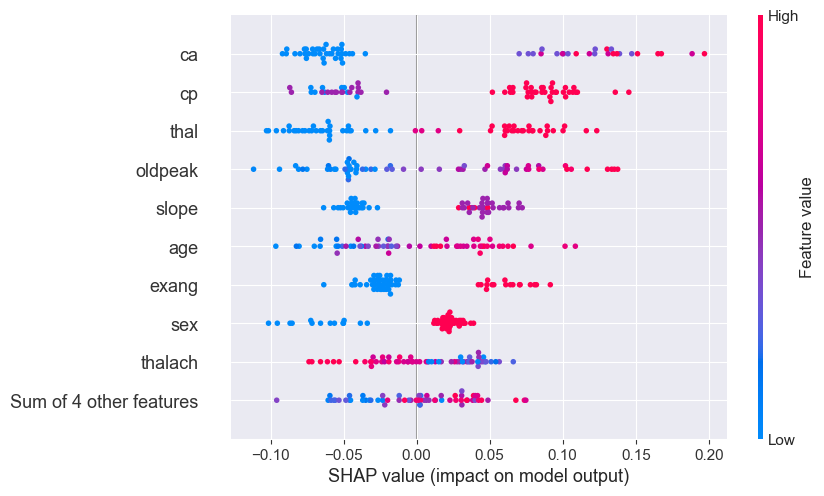


SHAP Feature Importance (Bar):


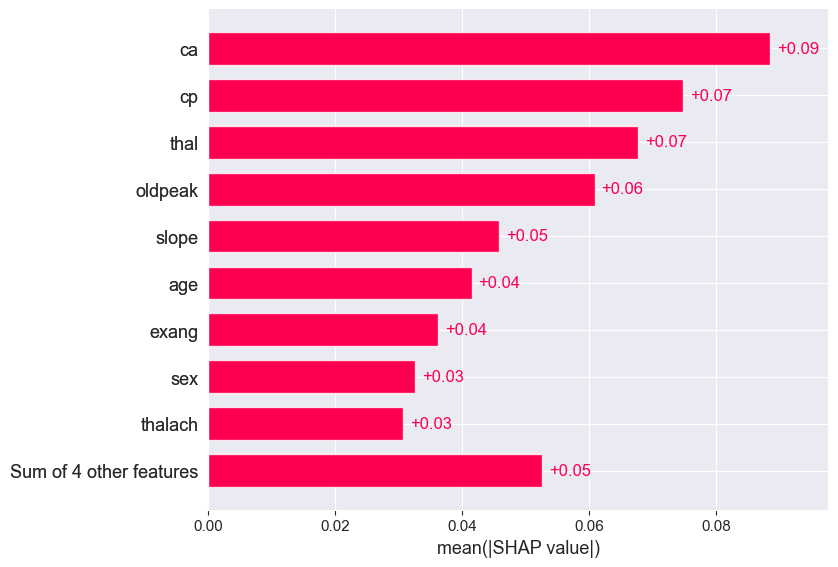


SHAP Waterfall Plot für den ersten Patienten:


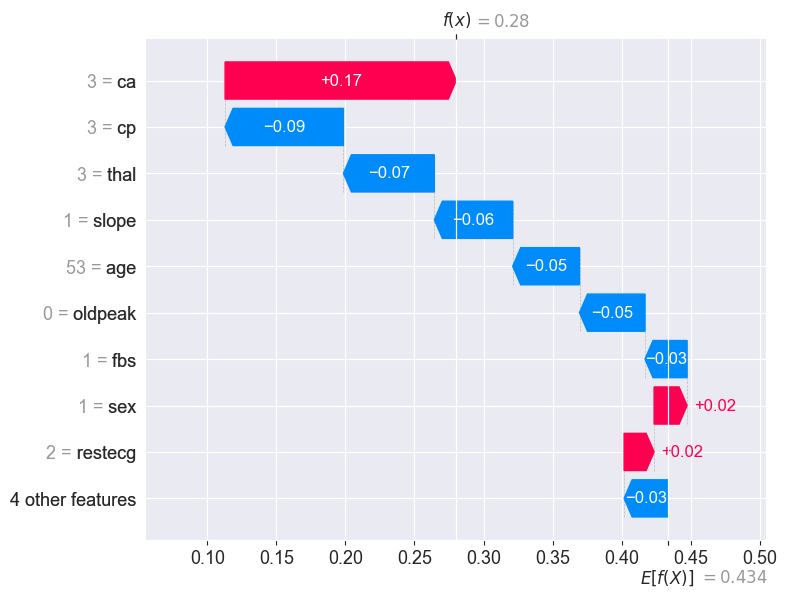

In [7]:
# --- SHAP-Analyse (Korrektur & Optimierung) ---
# Wir nutzen den modernen Explainer, der automatisch das passende Modell (Tree-based) erkennt
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# Bei Klassifikationsaufgaben (wie Random Forest) gibt SHAP oft Werte für beide Klassen aus [0, 1].
# Wir fokussieren uns auf Index 1 (Wahrscheinlichkeit für Herzerkrankung).
if len(shap_values.shape) == 3:
    shap_values_to_plot = shap_values[:, :, 1]
else:
    shap_values_to_plot = shap_values

# 1. Zusammenfassende Grafik (Beeswarm Plot - moderner Summary Plot)
print("SHAP Summary Plot (Beeswarm):")
shap.plots.beeswarm(shap_values_to_plot)

# 2. Balkendiagramm (Globale Feature Importance)
print("\nSHAP Feature Importance (Bar):")
shap.plots.bar(shap_values_to_plot)

# 3. Wasserfalldiagramm für die erste Vorhersage (Einzelinstanz)
print("\nSHAP Waterfall Plot für den ersten Patienten:")
# Zeigt, wie die Basis-Wahrscheinlichkeit durch einzelne Merkmale zum Endwert wurde
shap.plots.waterfall(shap_values_to_plot[0])

> **Interpretation:** Merkmale wie `ca` (Anzahl der Gefäße), `cp` (Brustschmerztyp) und `thal` haben den größten Einfluss. Hohe Werte bei `ca` erhöhen die Wahrscheinlichkeit für eine Herzerkrankung massiv.

## 4. LIME-Analyse (Lokale Interpretierbarkeit)
LIME zeigt uns für einen **spezifischen** Patienten, warum das Modell genau so entschieden hat. Wir vergleichen zwei unterschiedliche Testfälle.


--- LIME Erklärung für Patient Index 0 ---


/Users/cristallagus/miniconda3/envs/tf-final/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


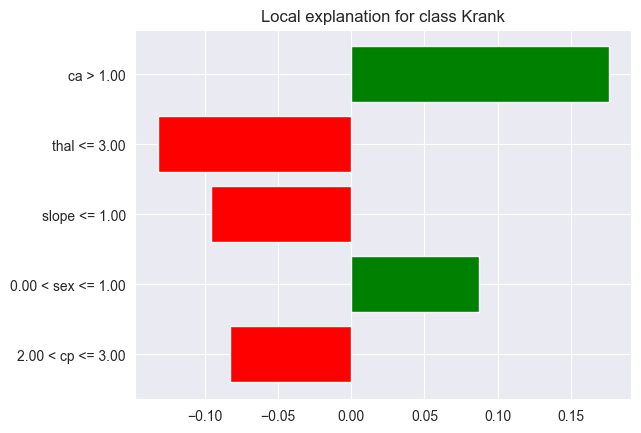


--- LIME Erklärung für Patient Index 1 ---


/Users/cristallagus/miniconda3/envs/tf-final/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


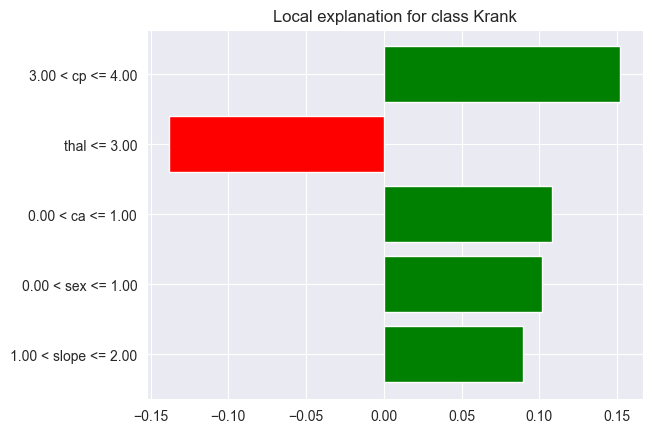

In [8]:
lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X.columns,
    class_names=['Gesund', 'Krank'],
    mode='classification'
)

# Erklärungen für zwei Patienten generieren
for i in range(2):
    print(f"\n--- LIME Erklärung für Patient Index {i} ---")
    exp = lime_explainer.explain_instance(X_test.iloc[i], model.predict_proba, num_features=5)
    exp.as_pyplot_figure()
    plt.show()

## 5. Geschäftsinterpretation & Reflexion
- **Klinischer Nutzen:** Erklärbarkeit fördert das Vertrauen von Medizinern. Wenn das Modell auf klinisch anerkannte Marker wie `ca` achtet, wird es eher akzeptiert.
- **SHAP vs. LIME:** SHAP bietet eine mathematisch konsistente Gesamtsicht, während LIME ideal ist, um einem Patienten eine individuelle Diagnose verständlich zu machen.
- **Fazit:** KI-Tools steigern die analytische Produktivität, indem sie die "Black Box" öffnen und fundierte Entscheidungen in sensiblen Bereichen ermöglichen.

### Vergleich der Erklärungen: SHAP vs. LIME
Beim Vergleich der Ergebnisse für Patient Index 0 fällt auf:
- **Konsistenz:** Beide Tools identifizieren ähnliche Hauptmerkmale (z.B. `ca` oder `cp`).
- **Unterschiede:** SHAP ist global konsistenter (basiert auf Spieltheorie), während LIME die Umgebung der Vorhersage lokal linear annähert. LIME kann in instabilen Regionen des Modells leicht abweichende Wichtigkeiten zeigen.
- **Praxis:** Im klinischen Alltag bietet LIME eine schnellere, "menschlichere" Erklärung, während SHAP für die Validierung des gesamten Modells durch die IT-Abteilung unerlässlich ist.